# 01 — Exploratory statistics and diagnostics

Section 2 (Statistical Foundations) of the Cross-Sectional Alpha Ranking project.

1. Raw data: stationarity and normality of prices vs. returns
2. Features: build and inspect
3. Stationarity of each feature (ADF + KPSS)
4. Cross-sectional and pooled distributions (skew, kurtosis, Jarque-Bera)
5. Winsorize + cross-sectional z-score
6. Multicollinearity (correlation, VIF)
7. Time-series vs cross-sectional z-score
8. Lookahead checklist
9. Label sanity and single-feature rank IC

In [19]:
import sys
from pathlib import Path

sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import diagnostics as d
from data import load
from features import FEATURES, build_features
from labels import make_labels, rebalance_dates
from models import ic_summary, rank_ic
from preprocess import preprocess

pd.set_option("display.precision", 3)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
BLUE, GRAY = "#2a6fdb", "#8c9099"

FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", dpi=150)

## 1. Raw data: prices vs. returns

In [20]:
px = load()
px["ret"] = np.log(px["close"]).groupby(px["ticker"]).diff()
print(px.shape, px["ticker"].nunique(), "tickers,", px["date"].min().date(), "to", px["date"].max().date())

(221233, 8) 91 tickers, 2014-06-02 to 2024-12-30


In [21]:
st_close = d.stationarity_table(px, "close")
st_ret = d.stationarity_table(px.dropna(subset=["ret"]), "ret")
pd.concat(
    {"close": st_close["verdict"].value_counts(), "log return": st_ret["verdict"].value_counts()},
    axis=1,
).fillna(0).astype(int)

,close,log return
verdict,,
non-stationary,91,0
stationary,0,85
ambiguous,0,6


In [22]:
ret = px["ret"].dropna()
pd.DataFrame(d.normality(ret), index=["pooled daily log return"])

,skew,excess_kurtosis,jb,jb_p
pooled daily log return,-0.2,13.062,1.574e+06,0.0


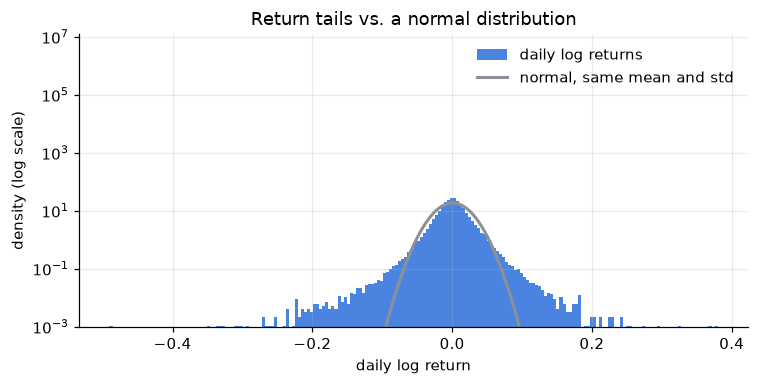

In [23]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(ret, bins=200, density=True, color=BLUE, alpha=0.85, label="daily log returns")
x = np.linspace(ret.min(), ret.max(), 400)
ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color=GRAY, lw=2, label="normal, same mean and std")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)
ax.set_xlabel("daily log return")
ax.set_ylabel("density (log scale)")
ax.set_title("Return tails vs. a normal distribution")
ax.legend(frameon=False)
save(fig, "returns_tails")

**To note for the report:** prices should come out non-stationary and returns stationary. KPSS p-values are clipped to the 0.01–0.10 range by statsmodels, so quote them as inequalities. Jarque-Bera will reject normality; the point is to document the fat tails.

## 2. Features

In [24]:
feats = build_features(px)
feats = feats[feats.index.get_level_values("date") >= "2015-01-01"].dropna()
flat = feats.reset_index()
print(feats.shape)
feats.describe().T

c:\Users\Eklavya\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(209514, 7)


,count,mean,std,min,25%,50%,75%,max
ret_5,209514.0,0.004,0.049,-0.538,-0.021,0.003,0.029,0.661
ret_20,209514.0,0.018,0.100,-0.786,-0.038,0.014,0.069,1.191
ret_60,209514.0,0.057,0.186,-0.811,-0.051,0.043,0.146,2.486
vol_20,209514.0,0.019,0.009,0.003,0.013,0.017,0.023,0.145
relvol_20,209514.0,-0.144,0.555,-4.726,-0.474,-0.165,0.171,2.805
rsi_14,209514.0,52.569,12.320,7.610,43.978,52.571,61.174,98.731
macd_norm,209514.0,0.003,0.028,-0.826,-0.009,0.005,0.017,0.143


## 3. Stationarity of each feature (per ticker, ADF + KPSS)

In [25]:
rows = []
for f in FEATURES:
    t = d.stationarity_table(flat, f)
    rows.append(t["verdict"].value_counts().rename(f))
pd.concat(rows, axis=1).fillna(0).astype(int).T

verdict,stationary,ambiguous,non-stationary
ret_5,84,7,0
ret_20,76,15,0
ret_60,52,37,2
vol_20,38,52,1
relvol_20,81,10,0
rsi_14,59,32,0
macd_norm,70,21,0


Counts are tickers per verdict. Overlapping windows (the 60-day return, 20-day volatility) are serially correlated by construction; that affects standard errors, not the stationarity verdict.

## 4. Distributions: pooled and cross-sectional

In [26]:
norm_raw = d.normality_table(flat, FEATURES)
norm_raw

,skew,excess_kurtosis,jb,jb_p
ret_5,0.441,7.817,5.402e+05,0.000e+00
ret_20,0.621,6.918,4.313e+05,0.000e+00
ret_60,1.354,9.173,7.986e+05,0.000e+00
vol_20,2.580,13.087,1.728e+06,0.000e+00
relvol_20,0.027,2.158,4.066e+04,0.000e+00
rsi_14,-0.014,-0.210,3.918e+02,8.296e-86
macd_norm,-4.157,69.456,4.272e+07,0.000e+00


In [27]:
cs_rows = {}
for f in FEATURES:
    m = d.cross_sectional_moments(flat, f)
    cs_rows[f] = {
        "median_skew": m["skew"].median(),
        "p95_abs_skew": m["skew"].abs().quantile(0.95),
        "median_ex_kurt": m["excess_kurtosis"].median(),
        "p95_ex_kurt": m["excess_kurtosis"].quantile(0.95),
    }
pd.DataFrame(cs_rows).T

,median_skew,p95_abs_skew,median_ex_kurt,p95_ex_kurt
ret_5,4.585e-01,2.652,1.789,13.167
ret_20,5.231e-01,2.852,1.307,14.512
ret_60,6.367e-01,3.485,1.538,19.546
vol_20,1.273e+00,3.226,2.182,14.665
relvol_20,2.597e-01,1.289,1.189,5.080
rsi_14,9.454e-02,0.741,-0.145,1.022
macd_norm,-4.062e-04,2.725,1.156,13.901


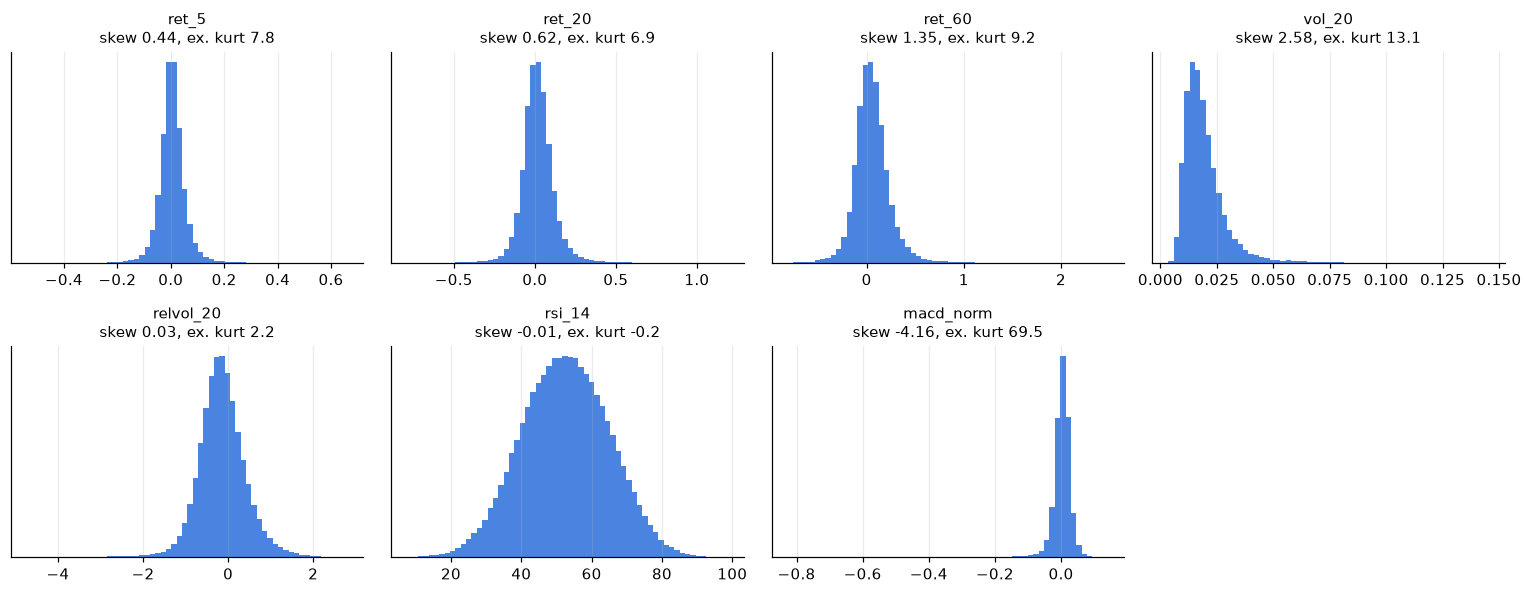

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5.5))
for ax, f in zip(axes.ravel(), FEATURES):
    ax.hist(flat[f], bins=60, color=BLUE, alpha=0.85)
    ax.set_title(f"{f}\nskew {flat[f].skew():.2f}, ex. kurt {flat[f].kurt():.1f}", fontsize=10)
    ax.set_yticks([])
axes.ravel()[-1].set_visible(False)
save(fig, "feature_distributions_raw")

## 5. Winsorize + cross-sectional z-score

In [29]:
z = preprocess(feats)
zf = z.reset_index()

g = z.groupby(level="date")
print("max |mean| per date:", g.mean().abs().max().max())
print("max |std - 1| per date:", (g.std() - 1).abs().max().max())

pd.concat(
    {
        "raw": norm_raw[["skew", "excess_kurtosis"]],
        "processed": d.normality_table(zf, FEATURES)[["skew", "excess_kurtosis"]],
    },
    axis=1,
)

max |mean| per date: 1.2403871033743128e-15
max |std - 1| per date: 8.881784197001252e-16


raw                 processed                
            skew excess_kurtosis      skew excess_kurtosis
ret_5      0.441           7.817     0.213          -0.445
ret_20     0.621           6.918     0.249          -0.527
ret_60     1.354           9.173     0.342          -0.451
vol_20     2.580          13.087     0.693          -0.234
relvol_20  0.027           2.158     0.183          -0.554
rsi_14    -0.014          -0.210     0.073          -0.821
macd_norm -4.157          69.456     0.004          -0.567

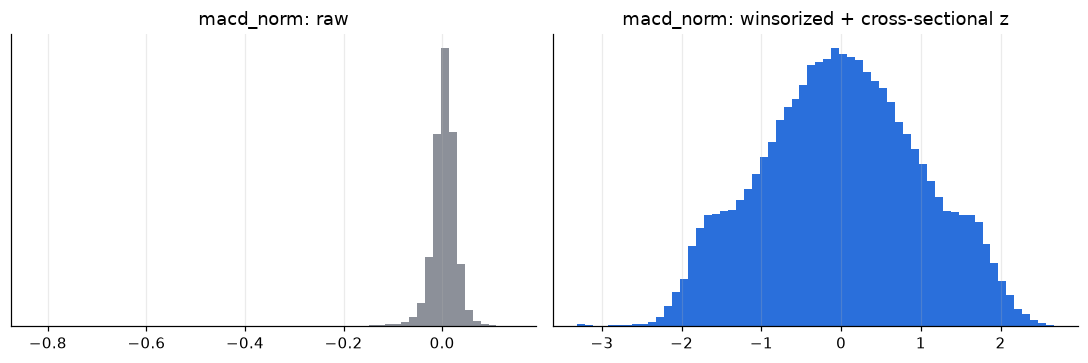

In [30]:
worst = norm_raw["excess_kurtosis"].idxmax()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(flat[worst], bins=60, color=GRAY)
axes[0].set_title(f"{worst}: raw")
axes[1].hist(zf[worst], bins=60, color=BLUE)
axes[1].set_title(f"{worst}: winsorized + cross-sectional z")
for ax in axes:
    ax.set_yticks([])
save(fig, "winsorize_zscore_effect")

## 6. Multicollinearity

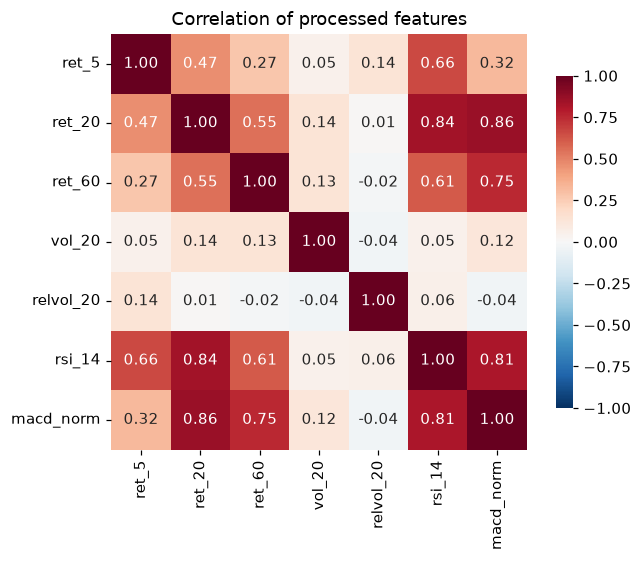

In [31]:
corr = z.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.grid(False)
ax.set_title("Correlation of processed features")
save(fig, "feature_correlation")

In [32]:
vif = d.vif(zf, FEATURES)
vif.to_frame().assign(flag_above_5=vif > 5)

,vif,flag_above_5
ret_5,2.402,False
ret_20,5.738,True
ret_60,2.667,False
vol_20,1.056,False
relvol_20,1.032,False
rsi_14,6.845,True
macd_norm,8.773,True


**To note for the report:** which features overlap and why (the return horizons nest; RSI is close to a short-horizon return). This overlap is the reason Ridge is preferred over plain OLS for the linear model.

## 7. The standardisation trap: time-series vs. cross-sectional z-score

In [33]:
f = "ret_20"
ts_z = flat.groupby("ticker")[f].transform(
    lambda s: (s - s.rolling(252, min_periods=60).mean()) / s.rolling(252, min_periods=60).std()
)
pair = pd.DataFrame({"ts_z": ts_z, "cs_z": zf[f]}).dropna()
print(f"{f}: corr(ts_z, cs_z) = {pair.corr().iloc[0, 1]:.2f}; "
      f"sign disagreement = {(np.sign(pair['ts_z']) != np.sign(pair['cs_z'])).mean():.1%}")

ret_20: corr(ts_z, cs_z) = 0.72; sign disagreement = 22.4%


The two operations answer different questions: a stock against its own history, or against its peers on one date. This project uses only the cross-sectional version, guarded by tests in `tests/test_preprocess.py`.

## 8. Lookahead checklist

| Feature | Definition at date t | Information used | Check |
|---|---|---|---|
| `ret_5`, `ret_20`, `ret_60` | close(t) / close(t−k) − 1 | closes up to t | `tests/test_features.py::test_no_lookahead` |
| `vol_20` | std of last 20 daily log returns | closes up to t | same test |
| `relvol_20` | log(volume(t) / trailing 20-day mean volume) | volumes up to t | same test |
| `rsi_14` | Wilder-smoothed gains/losses, per ticker | closes up to t | same test |
| `macd_norm` | (EMA12 − EMA26) / close, per ticker | closes up to t | same test |
| z-score | per-date mean and std across stocks | same-date features only | `tests/test_preprocess.py::test_no_cross_date_leakage` |
| labels | close(next rebalance) / close(t) − 1 | used only as the target | `tests/test_labels.py` |
| training rows | rows with label_end ≤ prediction date | known by then | `tests/test_splits.py`, `tests/test_models.py::test_no_lookahead_in_training` |

**Known limitations**

- Yahoo adjusted closes are restated retroactively at every dividend or split, so a value computed today is not exactly what was visible on date t.
- The universe is today's index constituents, so the sample carries survivorship bias.
- Transaction costs and slippage are applied in the backtest, not here.

## 9. Label sanity and single-feature rank IC

In [34]:
rb = rebalance_dates(px["date"].unique())
labels = make_labels(px, rb)
ds = z[z.index.get_level_values("date").isin(rb)].join(labels, how="inner").dropna()
print(len(rb), "rebalance dates;", ds.shape[0], "labelled rows")
ds[["fwd_ret", "fwd_ret_z", "beat_median"]].describe().T

127 rebalance dates; 10114 labelled rows


,count,mean,std,min,25%,50%,75%,max
fwd_ret,10114.0,1.815e-02,0.101,-0.682,-0.039,0.013,0.070,0.941
fwd_ret_z,10114.0,-1.734e-04,0.991,-5.051,-0.622,-0.070,0.535,7.354
beat_median,10114.0,4.964e-01,0.500,0.000,0.000,0.000,1.000,1.000


In [35]:
rows = {}
for f in FEATURES:
    tmp = ds[[f, "fwd_ret"]].rename(columns={f: "score"})
    rows[f] = ic_summary(rank_ic(tmp))
pd.DataFrame(rows).T

,mean_ic,std_ic,ic_ir,t_stat,hit_rate,n_dates
ret_5,-0.030,0.163,-0.187,-2.042,0.437,119.0
ret_20,-0.013,0.204,-0.062,-0.674,0.462,119.0
ret_60,0.008,0.197,0.038,0.418,0.529,119.0
vol_20,0.004,0.202,0.019,0.204,0.538,119.0
relvol_20,-0.009,0.137,-0.067,-0.727,0.487,119.0
rsi_14,-0.033,0.190,-0.175,-1.914,0.445,119.0
macd_norm,-0.015,0.199,-0.074,-0.806,0.454,119.0


Each row is the per-month Spearman correlation between one feature and the next month's return, summarised over months. These are in-sample descriptive numbers, not results: they only show whether any feature carries obvious signal before modelling.